# Modeling: recommendation experiments

## 1. Setup

In [1]:
from __future__ import annotations

import sys
from pathlib import Path


def _project_root() -> Path:
    here = Path.cwd().resolve()
    for p in [here, *here.parents]:
        if (p / "pyproject.toml").is_file():
            return p
    return (here / "..").resolve()


ROOT = _project_root()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import logging
import pandas as pd
import scipy
from typing import Dict

from loaders import DataLoader

data_loader = DataLoader()


## 2. Load train, test, and embeddings

In [2]:
import numpy as np

processed = ROOT / "data" / "processed"


def _read_clicks_temporal(stem: str) -> pd.DataFrame:
    pq, csv_gz = processed / f"{stem}.parquet", processed / f"{stem}.csv.gz"
    if pq.is_file():
        return pd.read_parquet(pq)
    if csv_gz.is_file():
        return pd.read_csv(csv_gz, parse_dates=["click_timestamp"])
    raise FileNotFoundError(f"Missing {pq} or {csv_gz}; run EDA temporal split first.")


train_df = _read_clicks_temporal("clicks_train_temporal")
test_df = _read_clicks_temporal("clicks_test_temporal")
display(train_df.head())
print(train_df.shape)
print(f'Unique number of users in train: {train_df["user_id"].nunique()}')
display(test_df.head())
print(test_df.shape)
print(f'Unique number of users in test: {test_df["user_id"].nunique()}')

emb_npz = processed / "article_embeddings_temporal_union.npz"
if emb_npz.is_file():
    z = np.load(emb_npz)
    _ids = z["article_id"]
    _emb = z["embedding"]
    article_id_to_embedding = {int(_ids[i]): _emb[i].copy() for i in range(len(_ids))}
else:
    logging.warning(
        "Missing %s — falling back to full matrix (row i = article_id i). Run EDA temporal split to export npz.",
        emb_npz.name,
    )
    full = data_loader.load_article_embeddings_matrix()
    article_id_to_embedding = {i: full[i] for i in range(len(full))}

print(
    f"{len(article_id_to_embedding):,} article_id → embedding (subset for train∪test temporal split)"
)
_a0 = next(iter(article_id_to_embedding))
display(article_id_to_embedding[_a0][:8])

,user_id,session_id,session_start,session_size,click_timestamp,click_environment,click_deviceGroup,click_os,click_country,click_region,click_referrer_type,article_id,category_id,created_at_ts,publisher_id,words_count
0,137432,1507091833314122,2017-10-04 04:37:13,2,2017-10-04 04:37:50.976,4,4,2,1,5,2,157078,281,2017-10-03 20:03:46,0,269
1,137432,1507091833314122,2017-10-04 04:37:13,2,2017-10-04 04:38:20.976,4,4,2,1,5,2,161602,281,2017-10-03 16:10:27,0,248
2,151078,1507091871132126,2017-10-04 04:37:51,3,2017-10-04 04:38:02.993,4,1,17,10,28,2,207994,331,2017-10-03 20:54:01,0,177
3,151078,1507091871132126,2017-10-04 04:37:51,3,2017-10-04 04:39:54.483,4,1,17,10,28,2,206090,331,2017-10-03 23:03:43,0,244
4,151078,1507091871132126,2017-10-04 04:37:51,3,2017-10-04 04:40:24.483,4,1,17,10,28,2,156619,281,2017-10-03 11:44:02,0,275


(881392, 16)
Unique number of users in train: 64734


,user_id,session_id,session_start,session_size,click_timestamp,click_environment,click_deviceGroup,click_os,click_country,click_region,click_referrer_type,article_id,category_id,created_at_ts,publisher_id,words_count
0,93863,1507865792177843,2017-10-13 03:36:32,2,2017-10-13 03:37:12.925,4,3,2,1,21,2,96210,209,2017-10-12 08:59:51,0,274
1,93863,1507865792177843,2017-10-13 03:36:32,2,2017-10-13 03:37:42.925,4,3,2,1,21,2,158094,281,2017-10-12 10:22:31,0,223
2,77136,1507865796257845,2017-10-13 03:36:36,2,2017-10-13 03:42:13.178,4,3,2,1,25,2,336245,437,2017-10-12 05:18:51,0,150
3,77136,1507865796257845,2017-10-13 03:36:36,2,2017-10-13 03:42:43.178,4,3,2,1,25,2,96210,209,2017-10-12 08:59:51,0,274
4,16921,1507865798301846,2017-10-13 03:36:38,2,2017-10-13 03:37:38.065,4,1,17,1,9,1,159197,281,2017-10-12 17:43:34,0,299


(771758, 16)
Unique number of users in test: 64734
28,131 article_id → embedding (subset for train∪test temporal split)


array([-0.7008142 , -0.9659266 , -0.1818693 , -0.42350376, -0.02466794,
        0.18706073, -0.67465675, -0.10877775], dtype=float32)

In [ ]:
train_df.reset_index(drop=True).groupby("user_id").size().describe()

count    64734.000000
mean        13.615596
std         14.515561
min          1.000000
25%          5.000000
50%          9.000000
75%         17.000000
max        552.000000
dtype: float64

In [ ]:
(train_df.reset_index(drop=True).groupby("user_id").size() == 1).sum()

np.int64(40)

## 3. Modeling


### 3.1 Content-based



Content-based filtering approaches leverage description or attributes from items the user has interacted to recommend similar items. It depends only on the user previous choices, making this method robust to avoid the cold-start problem. For textual items, like articles, news and books, it is simple to use the raw text to build item profiles and user profiles.

Here, the articles texts features and metadata  inputs were combined by using a sequence of Fully Connected (FC) layers in a 1D CNN neural network model to produce Article Content Embeddings.

1. To model the user profile, we take all the item profiles the user has interacted and average them. The average is weighted by the interaction strength, in other words, the articles the user has interacted the most (clicked) will have a higher strength in the final user profile.

In [9]:
from typing import Dict, List, Set, Any, Optional

class CBRecommender:
    """
    Content-Based recommender for experimentation.
    Allows testing and combining profiles: Mean, Recency, and Category Weighted.
    """
    def __init__(self, data_loader, user_col: str = "user_id", item_col: str = "article_id", timestamp_col: str = "click_timestamp"):
        self.data_loader = data_loader
        self.user_col = user_col
        self.item_col = item_col
        self.timestamp_col = timestamp_col

        # Global article catalogue data
        self.candidate_ids: np.ndarray = np.array([])
        self.candidate_embeddings: np.ndarray = np.array([[]])
        self.candidate_norms: np.ndarray = np.array([])

        # Metadata dictionaries (O(1) access)
        self.article_to_idx: Dict[int, int] = {}
        self.category_by_article: Dict[int, int] = {}
        self.created_ts_by_article: Dict[int, int] = {}

        # User profiles calculated
        self.user_profiles: Dict[int, np.ndarray] = {}
        self.user_seen: Dict[int, Set[int]] = {}

    def fit(self, train_df: pd.DataFrame, strategy: str = "mean", half_life_days: float = 7.0, top_n_categories: Optional[int] = None):
        """
        Trains the model according to the chosen strategy.
        Available strategies: 'mean', 'recency', 'category'
        """
        print("1/3. Loading and indexing article catalogue...")
        self.candidate_ids = train_df[self.item_col].dropna().astype(int).unique()
        self.article_to_idx = {int(aid): i for i, aid in enumerate(self.candidate_ids)}

        # Retrieving all necessary embeddings at once
        emb = self.data_loader.get_embeddings_by_ids(self.candidate_ids.tolist())
        self.candidate_embeddings = np.asarray(emb, dtype=np.float32)

        # Pre-calculating norms for cosine
        self.candidate_norms = np.linalg.norm(self.candidate_embeddings, axis=1)
        self.candidate_norms = np.where(self.candidate_norms == 0.0, 1e-12, self.candidate_norms)

        # Loading metadata via data_loader
        self.category_by_article = self.data_loader.get_category_map(self.candidate_ids)
        self.created_ts_by_article = self.data_loader.get_article_created_ts_map(self.candidate_ids)

        print("2/3. Mapping user histories...")
        # Native storage of seen items for masking at recommendation time
        seen_grouped = train_df.groupby(self.user_col)[self.item_col].apply(set).to_dict()
        self.user_seen = {int(k): {int(i) for i in v} for k, v in seen_grouped.items()}

        print(f"3/3. Calculating user profiles according to strategy: '{strategy}'...")
        # Extracting interactions sorted by time if recency is required
        if strategy == "recency":
            train_df = train_df.sort_values(by=[self.user_col, self.timestamp_col])

        user_groups = train_df.groupby(self.user_col)

        for uid, group in user_groups:
            aids = group[self.item_col].dropna().astype(int).tolist()
            user_emb = self.data_loader.get_embeddings_by_ids(aids)

            if user_emb.size == 0:
                continue

            if strategy == "mean":
                # Simple Mean Profile
                self.user_profiles[int(uid)] = user_emb.mean(axis=0)

            elif strategy == "recency":
                # Recency Profile: Exponential decay based on click order (simulated here by recent index)
                # The more recent the click, the stronger its weight
                n_clicks = len(aids)
                # Simple linear time constant for experimentation
                weights = np.exp(np.linspace(-2.0, 0.0, n_clicks))
                weights /= weights.sum()
                self.user_profiles[int(uid)] = np.dot(weights, user_emb)

            elif strategy == "category" and top_n_categories is not None:
                # Category Profile: Overweight embeddings of articles belonging to top categories
                cats = [self.category_by_article.get(aid) for aid in aids if self.category_by_article.get(aid) is not None]
                if cats:
                    counts = pd.Series(cats).value_counts().head(top_n_categories)
                    top_cats = set(counts.index)

                    # We apply a boost to the articles of the history that have the right category
                    weights = np.array([2.0 if self.category_by_article.get(aid) in top_cats else 1.0 for aid in aids])
                    weights /= weights.sum()
                    self.user_profiles[int(uid)] = np.dot(weights, user_emb)
                else:
                    self.user_profiles[int(uid)] = user_emb.mean(axis=0)
            else:
                # Fallback by default
                self.user_profiles[int(uid)] = user_emb.mean(axis=0)

        print("Model ready for predictions.")
        return self

    def recommend_batch(self, user_ids: List[int], n: int = 5) -> Dict[int, List[int]]:
        """Calculate Top-N in a vectorized way for a batch of users."""
        recs: Dict[int, List[int]] = {}

        for uid in user_ids:
            profile = self.user_profiles.get(uid)
            if profile is None:
                continue

            u_norm = np.linalg.norm(profile)
            if u_norm == 0:
                continue

            # Critical step: Pure matrix product (364 047 cosine calculations at once)
            scores = (self.candidate_embeddings @ profile) / (self.candidate_norms * u_norm)

            # Ultra-fast masking of already seen items (push them to -infinity)
            seen_set = self.user_seen.get(uid, set())
            seen_indices = [self.article_to_idx[aid] for aid in seen_set if aid in self.article_to_idx]
            if seen_indices:
                scores[seen_indices] = -np.inf

            # Retrieving the N best elements without sorting the whole array (np.argpartition)
            if len(scores) > n:
                top_indices = np.argpartition(scores, -n)[-n:]
                top_indices = top_indices[np.argsort(scores[top_indices])[::-1]]
            else:
                top_indices = np.argsort(scores)[::-1]

            recs[uid] = self.candidate_ids[top_indices].tolist()

        return recs

    def evaluate(self, test_df: pd.DataFrame, topk: int = 5) -> float:
        """Calculate Hit Rate (Top-N Accuracy) at scale."""
        test_grouped = test_df.groupby(self.user_col)[self.item_col].apply(set).to_dict()
        user_ids = list(test_grouped.keys())

        all_recs = self.recommend_batch(user_ids, n=topk)

        hits = []
        for uid in user_ids:
            true_items = test_grouped[uid]
            predicted_items = all_recs.get(uid, [])
            hit = 1.0 if any(item in true_items for item in predicted_items) else 0.0
            hits.append(hit)

        return float(np.mean(hits).round(4))

In [32]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

def plot_user_recommendations_2d(user_id: int, recommender, df_train: pd.DataFrame, df_test: pd.DataFrame, recommendations: list, data_loader):
    """
    Plots a 2D PCA graph of the user profile, history, and recommendations.
    """
    # 1. IDs of articles
    train_aids = df_train.loc[df_train[recommender.user_col] == user_id, recommender.item_col].dropna().astype(int).tolist()
    test_aids = df_test.loc[df_test[recommender.user_col] == user_id, recommender.item_col].dropna().astype(int).tolist()
    rec_aids = list(recommendations)

    if not train_aids:
        print(f"⚠️ No history in the Train for user {user_id}. Impossible to plot the graph.")
        return

    # 2. User profile
    user_profile = recommender.user_profiles.get(user_id)
    if user_profile is None:
        print(f"⚠️ No profile found for user {user_id} (absent from model).")
        return
    user_profile = user_profile.reshape(1, -1)

    # 3. Secure retrieval of embeddings (Train, Test, Recs)
    train_embs = data_loader.get_embeddings_by_ids(train_aids)
    test_embs = data_loader.get_embeddings_by_ids(test_aids) if test_aids else np.array([])
    rec_embs = data_loader.get_embeddings_by_ids(rec_aids) if rec_aids else np.array([])

    # 4. Stacking matrices for PCA
    matrices_to_stack = [train_embs]
    if test_embs.size > 0:
        matrices_to_stack.append(test_embs)
    if rec_embs.size > 0:
        matrices_to_stack.append(rec_embs)
    matrices_to_stack.append(user_profile)

    all_embs = np.vstack(matrices_to_stack)

    # 5. PCA projection in 2D
    pca = PCA(n_components=2, random_state=42)
    all_embs_2d = pca.fit_transform(all_embs)

    # 6. Splitting coordinates
    idx = 0
    train_2d = all_embs_2d[idx : idx + len(train_aids)]; idx += len(train_aids)

    test_2d = None
    if test_embs.size > 0:
        test_2d = all_embs_2d[idx : idx + len(test_aids)]; idx += len(test_aids)

    rec_2d = None
    if rec_embs.size > 0:
        rec_2d = all_embs_2d[idx : idx + len(rec_aids)]; idx += len(rec_aids)

    profile_2d = all_embs_2d[idx]

    # 7. Construction and display of the graph
    plt.figure(figsize=(11, 7))

    # Train history
    plt.scatter(train_2d[:, 0], train_2d[:, 1], color='royalblue', alpha=0.7, edgecolors='k', s=80, label=f'Historique Train ({len(train_aids)} items)')

    # Future real (Test) - optional if the user has nothing in the test
    if test_2d is not None:
        plt.scatter(test_2d[:, 0], test_2d[:, 1], color='limegreen', alpha=0.9, edgecolors='k', s=130, marker='X', label=f'Future Real Test ({len(test_aids)} items)')

    # Model recommendations
    if rec_2d is not None:
        plt.scatter(rec_2d[:, 0], rec_2d[:, 1], color='crimson', alpha=0.8, edgecolors='k', s=100, marker='^', label=f'Top-{len(rec_aids)} Recommendations')

    # The profile (center of gravity calculated)
    plt.scatter(profile_2d[0], profile_2d[1], color='gold', edgecolor='black', s=350, marker='*', label='User Profile (Center)', zorder=5)

    plt.title(f"Vector analysis for user {user_id}", fontsize=13, fontweight='bold')
    plt.xlabel(f"Principal Component 1 ({pca.explained_variance_ratio_[0]:.1%} var)")
    plt.ylabel(f"Principal Component 2 ({pca.explained_variance_ratio_[1]:.1%} var)")
    plt.legend(loc='best', frameon=True, shadow=True)
    plt.grid(True, linestyle='--', alpha=0.4)
    plt.show()

In [29]:
import random
USER_COL = "user_id"
ITEM_COL = "article_id"

# random.seed(EVAL_SEED)
demo_user1 = int(random.choice(test_df[USER_COL].unique()))
demo_user2 = int(random.choice(test_df[USER_COL].unique()))
print(f"Demo demo_user1={demo_user1} (present in both train and test from EDA split)")

print("Train history (used to build the profile):")
print(f"Demo demo_user1={demo_user1} read {len(train_df.loc[train_df[USER_COL] == demo_user1])} in the train set and {len(test_df.loc[test_df[USER_COL] == demo_user1])} in the test set")
print(f"Demo demo_user2={demo_user2} (present in both train and test from EDA split)")
print(f"Demo demo_user2={demo_user2} read {len(train_df.loc[train_df[USER_COL] == demo_user2])} in the train set and {len(test_df.loc[test_df[USER_COL] == demo_user2])} in the test set")

demo_users = [demo_user1, demo_user2]

Demo demo_user1=253399 (present in both train and test from EDA split)
Train history (used to build the profile):
Demo demo_user1=253399 read 2 in the train set and 6 in the test set
Demo demo_user2=38145 (present in both train and test from EDA split)
Demo demo_user2=38145 read 15 in the train set and 8 in the test set


In [37]:
CB_model = CBRecommender(data_loader=data_loader)

Testing strategy: Mean for user 253399
1/3. Loading and indexing article catalogue...
2/3. Mapping user histories...
3/3. Calculating user profiles according to strategy: 'mean'...
Model ready for predictions.
Number of accurate recommendations: 0


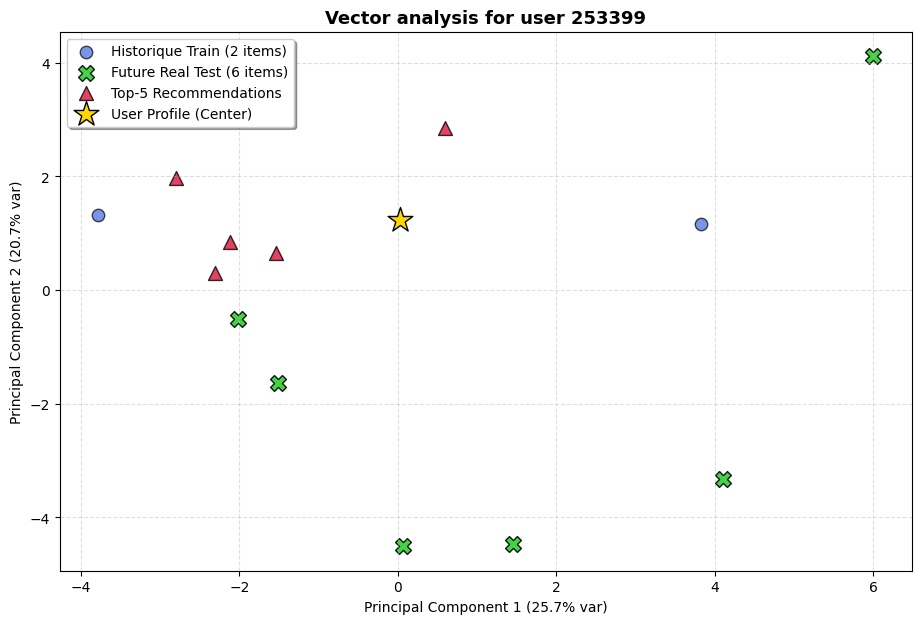

Testing strategy: Recency for user 253399
1/3. Loading and indexing article catalogue...
2/3. Mapping user histories...
3/3. Calculating user profiles according to strategy: 'recency'...
Model ready for predictions.


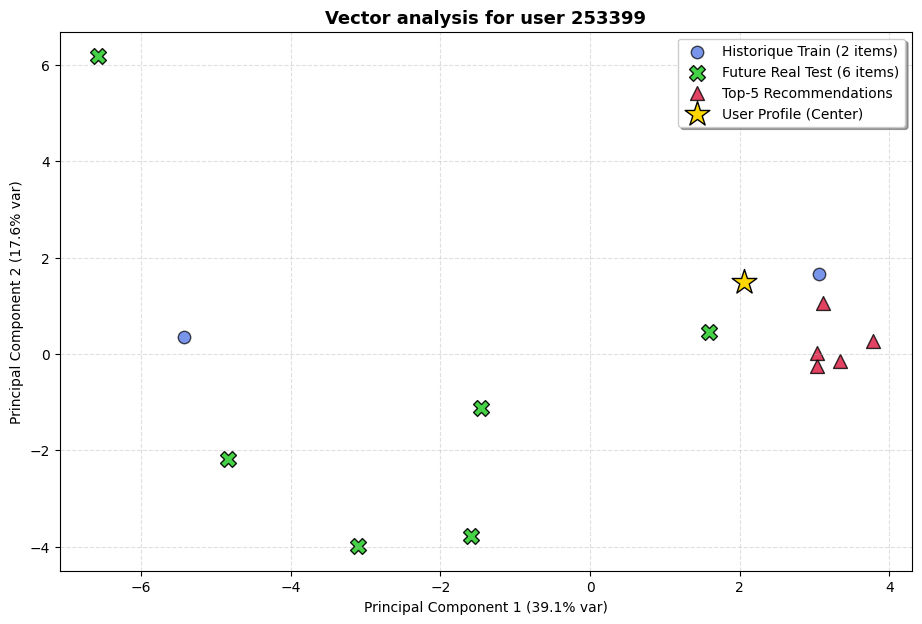

Testing strategy: Category for user 253399
1/3. Loading and indexing article catalogue...
2/3. Mapping user histories...
3/3. Calculating user profiles according to strategy: 'category'...
Model ready for predictions.


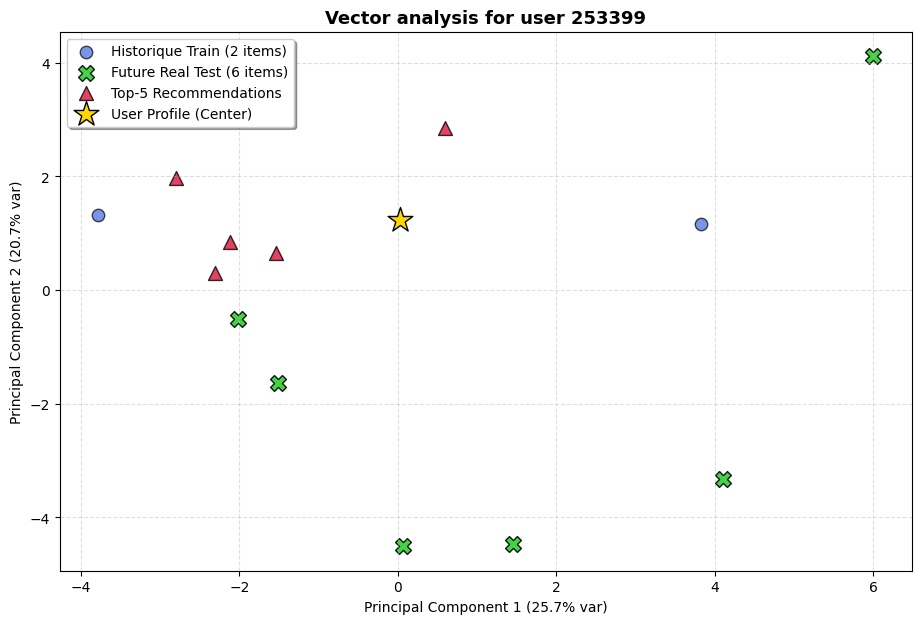

Testing strategy: Mean for user 38145
1/3. Loading and indexing article catalogue...
2/3. Mapping user histories...
3/3. Calculating user profiles according to strategy: 'mean'...
Model ready for predictions.
Number of accurate recommendations: 0


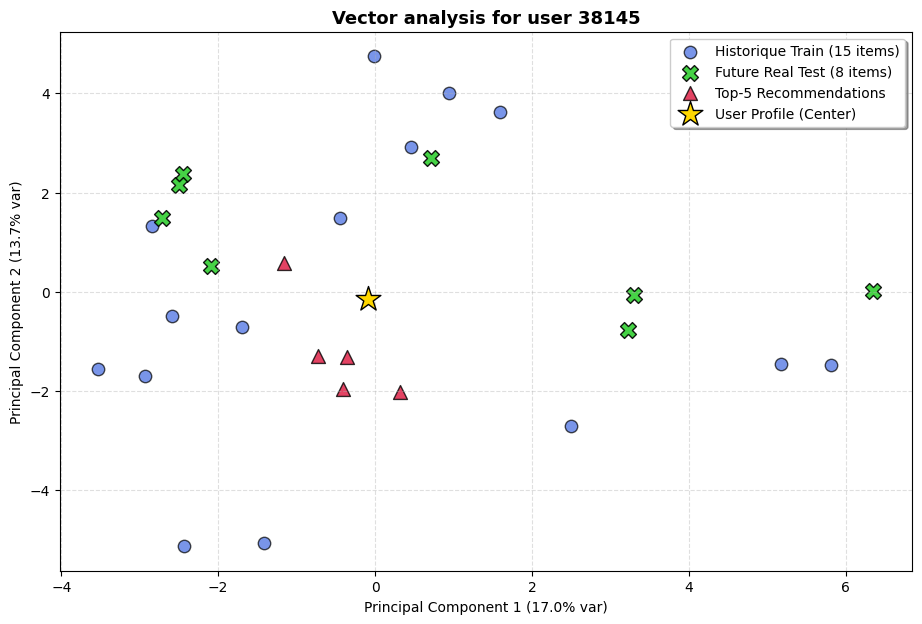

Testing strategy: Recency for user 38145
1/3. Loading and indexing article catalogue...
2/3. Mapping user histories...
3/3. Calculating user profiles according to strategy: 'recency'...
Model ready for predictions.


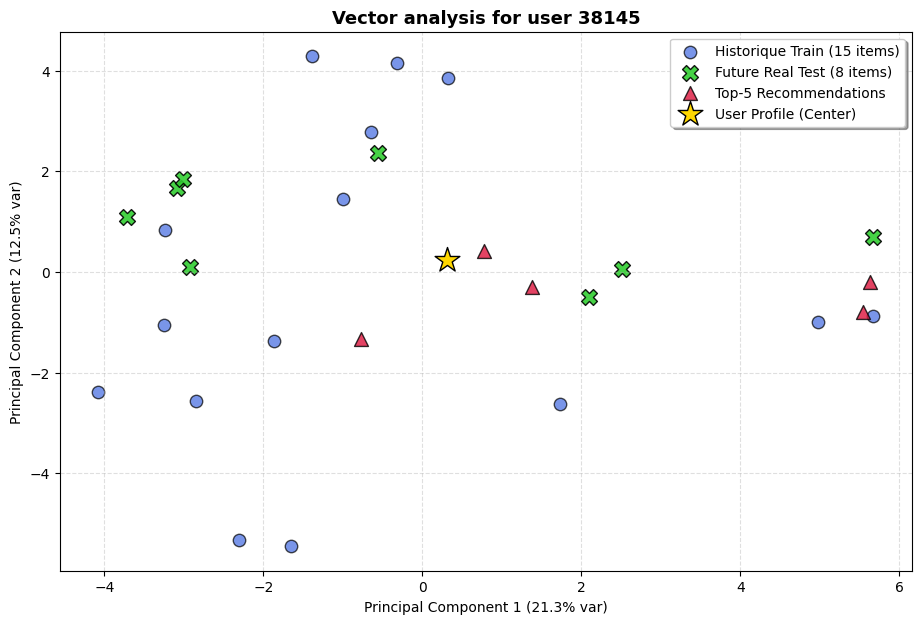

Testing strategy: Category for user 38145
1/3. Loading and indexing article catalogue...
2/3. Mapping user histories...
3/3. Calculating user profiles according to strategy: 'category'...
Model ready for predictions.


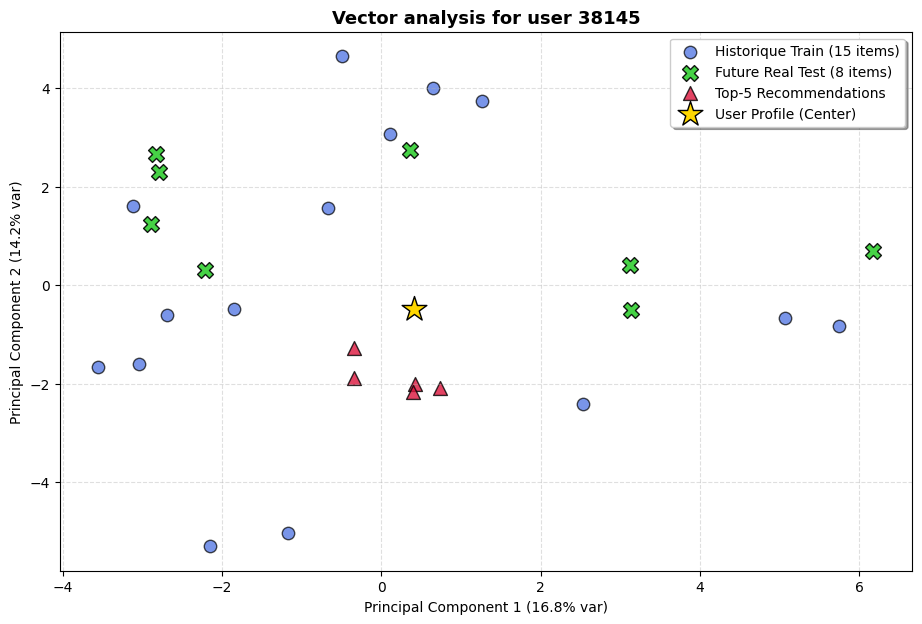

In [ ]:
for demo_user in demo_users:
    # --- TEST 1 : MEAN STRATEGY ---
    print(f"Testing strategy: Mean for user {demo_user}")
    CB_model.fit(train_df, strategy="mean")
    recs_mean = CB_model.recommend_batch([demo_user], n=5).get(demo_user, [])
    print(f"Number of accurate recommendations: {sum(1 for item in recs_mean if item in test_df.loc[test_df[USER_COL] == demo_user, ITEM_COL].dropna().astype(int).tolist())}")

    # Call the graph function
    plot_user_recommendations_2d(demo_user, CB_model, train_df, test_df, recs_mean, data_loader)


    # --- TEST 2 : RECENCY STRATEGY ---
    print(f"Testing strategy: Recency for user {demo_user}")
    CB_model.fit(train_df, strategy="recency")
    recs_recency = CB_model.recommend_batch([demo_user], n=5).get(demo_user, [])

    # Call the graph function (the star will move!)
    plot_user_recommendations_2d(demo_user, CB_model, train_df, test_df, recs_recency, data_loader)

    # --- TEST 3 : CATEGORY STRATEGY ---
    print(f"Testing strategy: Category for user {demo_user}")
    CB_model.fit(train_df, strategy="category", top_n_categories=2)
    recs_category = CB_model.recommend_batch([demo_user], n=5).get(demo_user, [])

    # Call the graph function (the star will move!)
    plot_user_recommendations_2d(demo_user, CB_model, train_df, test_df, recs_category, data_loader)


#### Baseline ( Average profile)

In [ ]:
CB_model.fit(train_df, strategy="mean")

# Évaluation directe
acc5_mean = CB_model.evaluate(test_df, topk=5)
acc10_mean = CB_model.evaluate(test_df, topk=10)

# Save results
results_df = pd.DataFrame({
    "strategy": ["mean"],
    "acc@5": [acc5_mean],
    "acc@10": [acc10_mean]
})
display(results_df)

1/3. Loading and indexing article catalogue...
2/3. Mapping user histories...
3/3. Calculating user profiles according to strategy: 'mean'...
Model ready for predictions.


,strategy,acc@5,acc@10
0,mean,0.0045,0.0085


#### Temporal recency

In [ ]:
CB_model.fit(train_df, strategy="recency")

acc5_rec = CB_model.evaluate(test_df, topk=5)
acc10_rec = CB_model.evaluate(test_df, topk=10)

# Add results to the DataFrame
results_df = pd.concat([results_df, pd.DataFrame({
    "strategy": ["recency"],
    "acc@5": [acc5_rec],
    "acc@10": [acc10_rec]
})])
display(results_df)

1/3. Loading and indexing article catalogue...
2/3. Mapping user histories...
3/3. Calculating user profiles according to strategy: 'recency'...
Model ready for predictions.


,strategy,acc@5,acc@10
0,mean,0.0045,0.0085
0,recency,0.0041,0.0081


#### Top N categories

In [ ]:
CB_model.fit(train_df, strategy="category", top_n_categories=3)

acc5_cat = CB_model.evaluate(test_df, topk=5)
acc10_cat = CB_model.evaluate(test_df, topk=10)

# Add results to the DataFrame
results_df = pd.concat([results_df, pd.DataFrame({
    "strategy": ["category"],
    "acc@5": [acc5_cat],
    "acc@10": [acc10_cat]
})])
display(results_df)

1/3. Loading and indexing article catalogue...
2/3. Mapping user histories...
3/3. Calculating user profiles according to strategy: 'category'...
Model ready for predictions.


,strategy,acc@5,acc@10
0,mean,0.0045,0.0085
0,recency,0.0041,0.0081
0,category,0.0053,0.0097
0,category,0.0053,0.0097


### 3.2 Collaborative filtering (implicit)

CF uses a sparse **user × item** matrix (SciPy sparse) from `train_df` and models from the [implicit](https://github.com/benfred/implicit) library (implicit feedback = clicks).

| Strategy | Class | Idea |
|----------|-------|------|
| **Item–item** | `ItemItemCosineCollaborativeFilteringRecommender` | Memory-based: articles co-read by similar users |
| **ALS** | `ALSCollaborativeFilteringRecommender` | Matrix factorization (Alternating Least Squares) |
| **BPR** | `BPRCollaborativeFilteringRecommender` | Pairwise ranking (clicked > not clicked) |
| **LMF** | `LMFCollaborativeFilteringRecommender` | Logistic matrix factorization |


We use the number of clicks as a Confident Signal for ALS, LMF and Item-Item. For BPR, we'll make a binary version of this information.

Same evaluation protocol as content-based: `Recommender.evaluate()` on `df_test` with Top-N Accuracy@K.


In [ ]:
import implicit
from scipy.sparse import csr_matrix

print("Preparation of sparse matrices for 'implicit'...")

# 1. Create integer encodings (continuous indices) for users and articles
# This is mandatory for SciPy matrices to work without holes
user_categories = pd.Categorical(train_df[USER_COL])
item_categories = pd.Categorical(train_df[ITEM_COL])

train_df["user_idx"] = user_categories.codes
train_df["item_idx"] = item_categories.codes

# Mapping for later correspondence
user_to_idx = dict(zip(user_categories, user_categories.codes))
idx_to_user = {v: k for k, v in user_to_idx.items()}

item_to_idx = dict(zip(item_categories, item_categories.codes))
idx_to_item = {v: k for k, v in item_to_idx.items()}

# 2. Calculate weights (number of clicks per user/item pair)
grouped_train = train_df.groupby(["user_idx", "item_idx"]).size().reset_index(name="clicks")

# 3. Build the User x Items matrix (CSR format)
# implicit requires float32 for training
user_item_matrix = csr_matrix(
    (grouped_train["clicks"].astype(np.float32),
     (grouped_train["user_idx"], grouped_train["item_idx"])),
    shape=(len(user_categories.categories), len(item_categories.categories))
)

print(f"Matrix created : {user_item_matrix.shape[0]} users and {user_item_matrix.shape[1]} articles.")

Préparation des matrices creuses pour 'implicit'...
Matrix created : 64734 users and 16478 articles.


In [22]:
def evaluate_implicit_model(model, user_item_matrix, df_test, item_to_idx, idx_to_item, topk: int = 5) -> float:
    """Calculate the Hit Rate (Top-N Accuracy) for an implicit library model."""
    # Quick grouping of ground truth (Test)
    test_grouped = df_test.groupby(USER_COL)[ITEM_COL].apply(set).to_dict()

    # Make sure that all users in the test set are present in the train set
    valid_eval_users = [uid for uid in test_grouped.keys() if uid in user_to_idx]
    user_idxs = [user_to_idx[uid] for uid in valid_eval_users]

    if not user_idxs:
        return 0.0

    # Batch recommendation (handled natively in C++/Cuda by implicit, ultra fast)
    # filter_already_liked_items=True automatically removes history from train!
    ids, scores = model.recommend(
        userid=user_idxs,
        user_items=user_item_matrix,
        N=topk,
        filter_already_liked_items=True
    )

    hits = []
    for i, uid in enumerate(valid_eval_users):
        true_items = test_grouped[uid]

        # Convert matrix indices of implicit to real article IDs, ignoring item_idx if == -1
        predicted_items = [idx_to_item[item_idx] for item_idx in ids[i] if item_idx != -1]

        hit = 1.0 if any(item in true_items for item in predicted_items) else 0.0
        hits.append(hit)

    return float(np.mean(hits).round(4))

In [23]:
print("Training the Item-Item model...")
model_item_item = implicit.nearest_neighbours.CosineRecommender(K=20)
model_item_item.fit(user_item_matrix)

acc5_ii = evaluate_implicit_model(model_item_item, user_item_matrix, test_df, item_to_idx, idx_to_item, topk=5)
acc10_ii = evaluate_implicit_model(model_item_item, user_item_matrix, test_df, item_to_idx, idx_to_item, topk=10)

# Save results in new df
CF_results_df = pd.DataFrame({
    "strategy": ["item-item"],
    "acc@5": [acc5_ii],
    "acc@10": [acc10_ii]
})
display(CF_results_df)


print("Training the ALS model...")
# Apply the recommended scaling alpha for implicit data (ex: Hu & Koren)
alpha_val = 40
scaled_matrix = (user_item_matrix * alpha_val).astype('float32')

model_als = implicit.als.AlternatingLeastSquares(factors=64, regularization=0.1, iterations=15, random_state=42)
model_als.fit(scaled_matrix)

acc5_als = evaluate_implicit_model(model_als, user_item_matrix, test_df, item_to_idx, idx_to_item, topk=5)
acc10_als = evaluate_implicit_model(model_als, user_item_matrix, test_df, item_to_idx, idx_to_item, topk=10)

# Save results
CF_results_df = pd.concat([CF_results_df, pd.DataFrame({
    "strategy": ["als"],
    "acc@5": [acc5_als],
    "acc@10": [acc10_als]
})])
display(CF_results_df)

print("Training the BPR model...")
# The BPR uses only a binary matrix (0 or 1)
bpr_matrix = user_item_matrix.copy()
bpr_matrix.data = np.ones_like(bpr_matrix.data)

model_bpr = implicit.bpr.BayesianPersonalizedRanking(factors=64, regularization=0.01, iterations=30, random_state=42)
model_bpr.fit(bpr_matrix)

acc5_bpr = evaluate_implicit_model(model_bpr, user_item_matrix, test_df, item_to_idx, idx_to_item, topk=5)
acc10_bpr = evaluate_implicit_model(model_bpr, user_item_matrix, test_df, item_to_idx, idx_to_item, topk=10)


# Save results
CF_results_df = pd.concat([CF_results_df, pd.DataFrame({
    "strategy": ["bpr"],
    "acc@5": [acc5_bpr],
    "acc@10": [acc10_bpr]
})])
display(CF_results_df)

print("Training the LMF model...")
model_lmf = implicit.lmf.LogisticMatrixFactorization(factors=64, regularization=0.6, iterations=30, random_state=42)
model_lmf.fit(user_item_matrix)

acc5_lmf = evaluate_implicit_model(model_lmf, user_item_matrix, test_df, item_to_idx, idx_to_item, topk=5)
acc10_lmf = evaluate_implicit_model(model_lmf, user_item_matrix, test_df, item_to_idx, idx_to_item, topk=10)

# Save results
CF_results_df = pd.concat([CF_results_df, pd.DataFrame({
    "strategy": ["lmf"],
    "acc@5": [acc5_lmf],
    "acc@10": [acc10_lmf]
})])
display(CF_results_df)

/Users/ikusawalaetitia/Documents/oc-projects/python/aiengineer/P10-content_recommandation_app/.venv/lib/python3.12/site-packages/implicit/utils.py:164: ParameterWarning: Method expects CSR input, and was passed coo_matrix instead. Converting to CSR took 0.004517316818237305 seconds
  warnings.warn(


Training the Item-Item model...


  0%|          | 0/16478 [00:00<?, ?it/s]

100%|██████████| 16478/16478 [00:00<00:00, 120997.02it/s]


,strategy,acc@5,acc@10
0,item-item,0.01,0.0216


...

100%|██████████| 30/30 [00:04<00:00,  6.97it/s, train_auc=78.26%, skipped=6.69%]


,strategy,acc@5,acc@10
0,item-item,0.0100,0.0216
0,als,0.0104,0.0171
0,bpr,0.0084,0.0151


Training the LMF model...


100%|██████████| 30/30 [00:21<00:00,  1.37it/s]


,strategy,acc@5,acc@10
0,item-item,0.0100,0.0216
0,als,0.0104,0.0171
0,bpr,0.0084,0.0151
0,lmf,0.0065,0.0132


ALS recommendations for user 253399
🚀 Top-5 Recommandations ALS for user 253399 :
[48403, 119193, 270229, 31836, 288320]
Real reading:
[236610, 283764, 337143, 342452, 354086, 128260]
Matching items:
[]


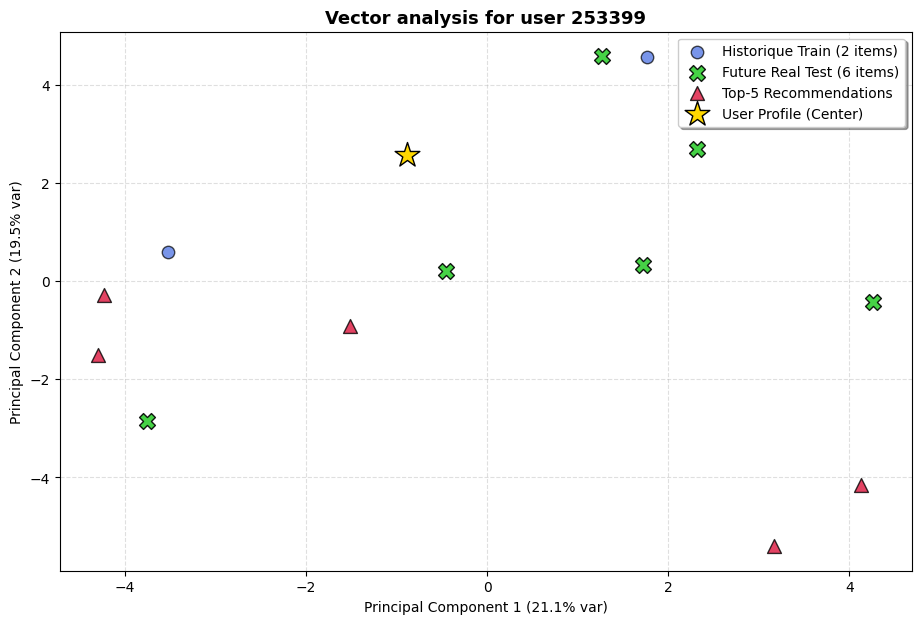

BPR recommendations for user 253399
🚀 Top-5 Recommandations BPR for user 253399 :
[288320, 123909, 48403, 199197, 276946]
Real reading:
[236610, 283764, 337143, 342452, 354086, 128260]
Matching items:
[]


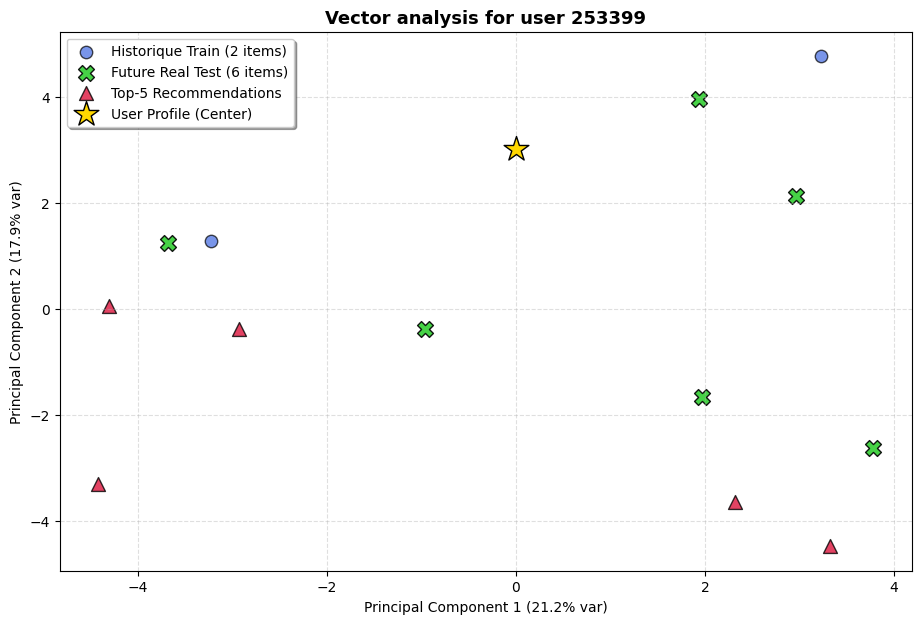

Item-Item recommendations for user 253399
🚀 Top-5 Recommandations Item-Item for user 253399 :
[48403, 270229, 288320, 133160, 119193]
Real reading:
[236610, 283764, 337143, 342452, 354086, 128260]
Matching items:
[]


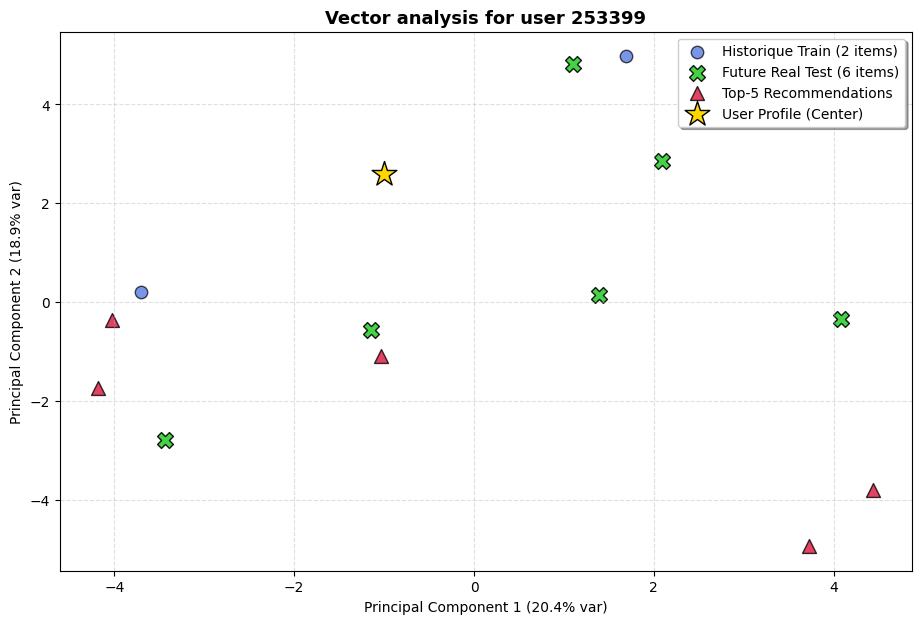

LMF recommendations for user 253399
🚀 Top-5 Recommandations LMF for user 253399 :
[235440, 198817, 58628, 233605, 284463]
Real reading:
[236610, 283764, 337143, 342452, 354086, 128260]
Matching items:
[]


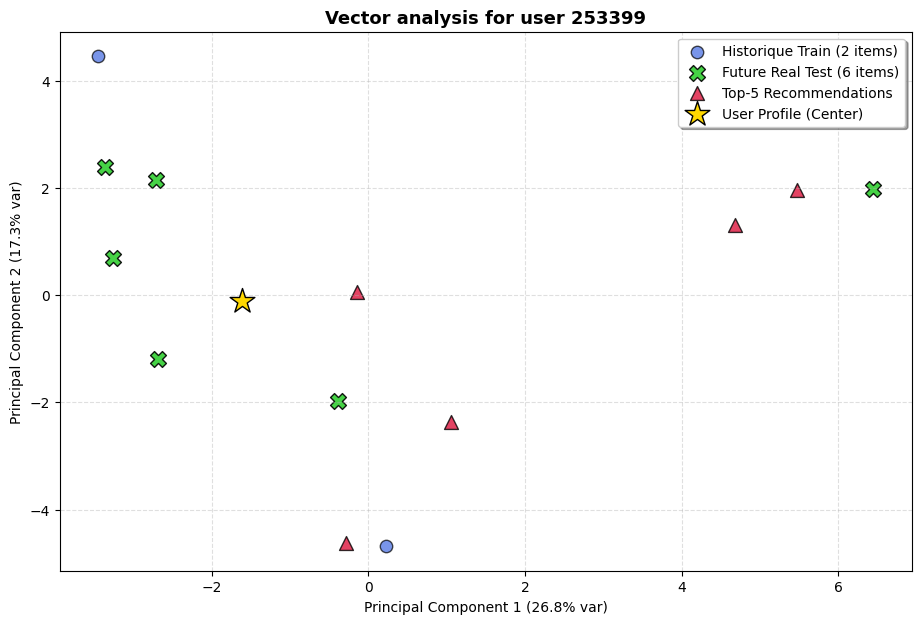

ALS recommendations for user 38145
🚀 Top-5 Recommandations ALS for user 38145 :
[198659, 233997, 313996, 324823, 299697]
Real reading:
[183176, 128260, 288435, 97546, 354086, 293513, 270607, 96986]
Matching items:
[]


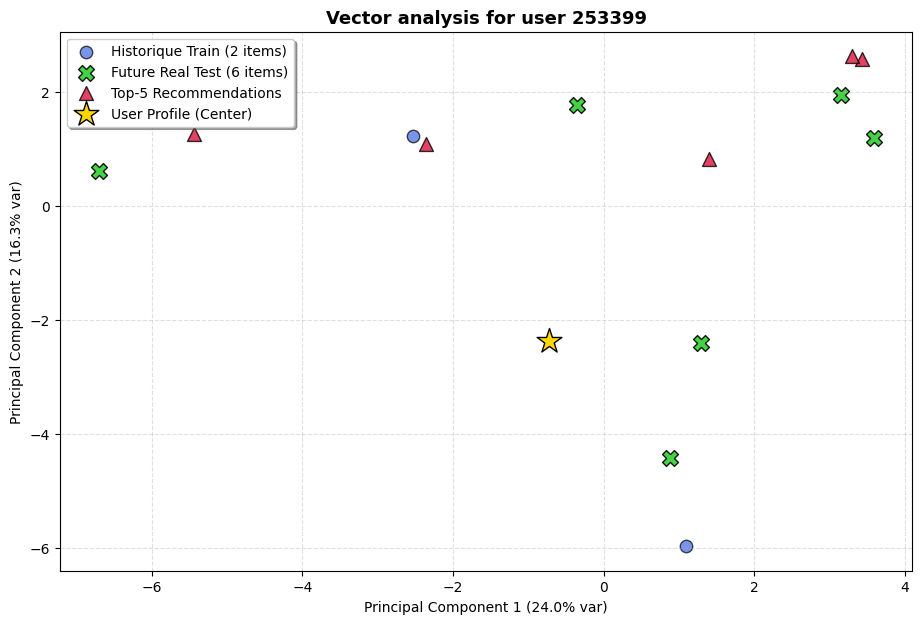

BPR recommendations for user 38145
🚀 Top-5 Recommandations BPR for user 38145 :
[284463, 338339, 97082, 83534, 336430]
Real reading:
[183176, 128260, 288435, 97546, 354086, 293513, 270607, 96986]
Matching items:
[]


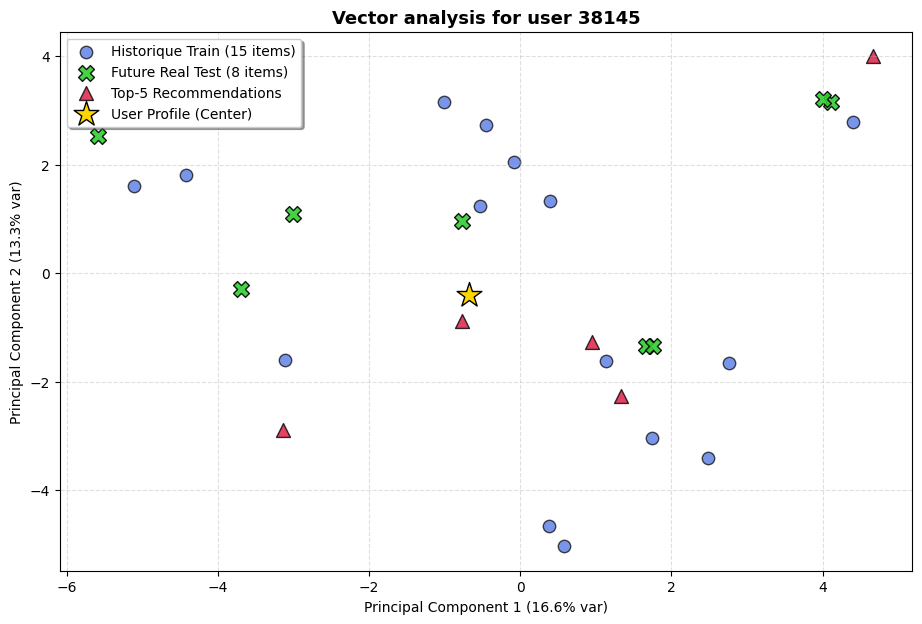

Item-Item recommendations for user 38145
🚀 Top-5 Recommandations Item-Item for user 38145 :
[64329, 272660, 199198, 175040, 198659]
Real reading:
[183176, 128260, 288435, 97546, 354086, 293513, 270607, 96986]
Matching items:
[]


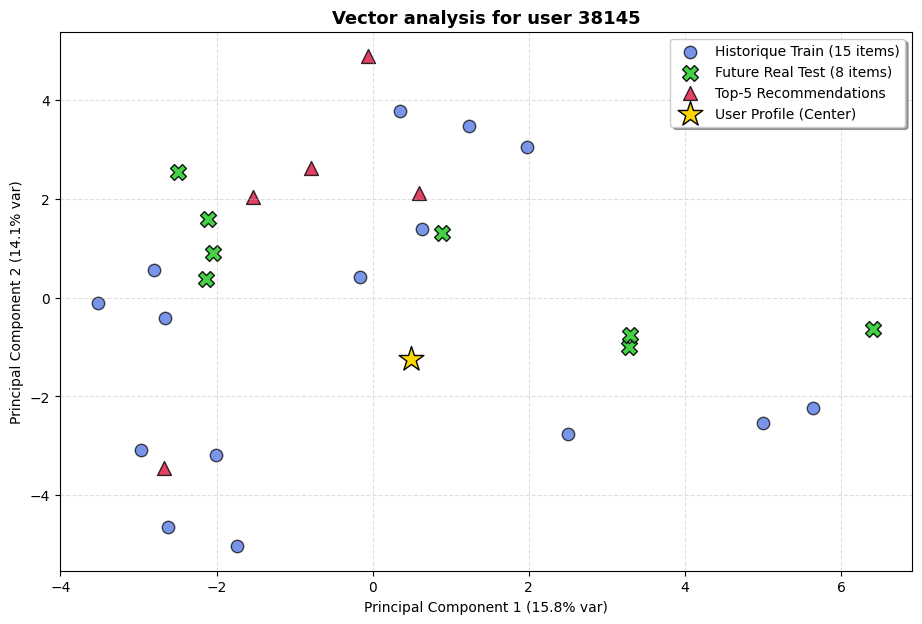

LMF recommendations for user 38145
🚀 Top-5 Recommandations LMF for user 38145 :
[71542, 205861, 156624, 149623, 124350]
Real reading:
[183176, 128260, 288435, 97546, 354086, 293513, 270607, 96986]
Matching items:
[]


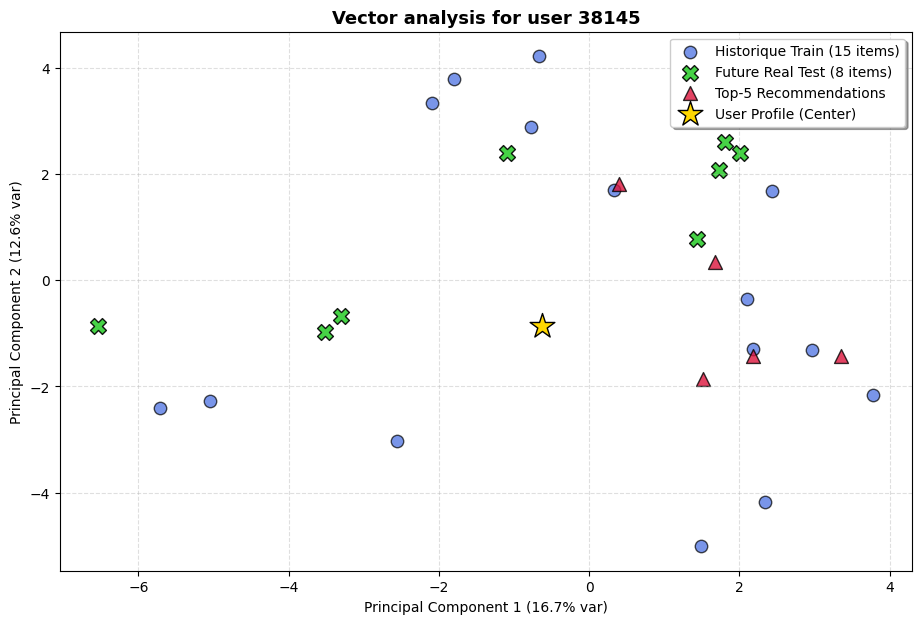

In [ ]:
for demo_user in demo_users:
    demo_user_idx = user_to_idx[demo_user]

    # Get ALS recommendations
    print(f"ALS recommendations for user {demo_user}")
    # implicit returns matrixes indexes, that we need to revert to articles id
    ids_indices, _ = model_als.recommend(
        userid=demo_user_idx,
        user_items=user_item_matrix[demo_user_idx],
        N=5,
        filter_already_liked_items=True
    )
    recs_als = [idx_to_item[idx] for idx in ids_indices]

    print(f"🚀 Top-5 Recommandations ALS for user {demo_user} :")
    print(recs_als)
    print("Real reading:")
    print(test_df.loc[test_df[USER_COL] == demo_user, ITEM_COL].dropna().astype(int).tolist())
    print("Matching items:")
    print([item for item in recs_als if item in test_df.loc[test_df[USER_COL] == demo_user, ITEM_COL].dropna().astype(int).tolist()])

    # plot CB to get the user profile
    plot_user_recommendations_2d(
        user_id=demo_user1,
        recommender=exp_model, # Keep CB to have the user profile
        df_train=train_df,
        df_test=test_df,
        recommendations=recs_als, # Using ALS recommendations!
        data_loader=data_loader
    )

    # Get BPR recommendations
    print(f"BPR recommendations for user {demo_user}")
    ids_indices, _ = model_bpr.recommend(
        userid=demo_user_idx,
        user_items=user_item_matrix[demo_user_idx],
        N=5,
        filter_already_liked_items=True
    )
    recs_bpr = [idx_to_item[idx] for idx in ids_indices]

    print(f"🚀 Top-5 Recommandations BPR for user {demo_user} :")
    print(recs_bpr)
    print("Real reading:")
    print(test_df.loc[test_df[USER_COL] == demo_user, ITEM_COL].dropna().astype(int).tolist())
    print("Matching items:")
    print([item for item in recs_bpr if item in test_df.loc[test_df[USER_COL] == demo_user, ITEM_COL].dropna().astype(int).tolist()])

    # plot CB to get the user profile
    plot_user_recommendations_2d(
        user_id=demo_user,
        recommender=CB_model, # Keep CB to have the user profile
        df_train=train_df,
        df_test=test_df,
        recommendations=recs_bpr, # Using BPR recommendations!
        data_loader=data_loader
    )

    print(f"Item-Item recommendations for user {demo_user}")
    ids_indices, _ = model_item_item.recommend(
        userid=demo_user_idx,
        user_items=user_item_matrix[demo_user_idx],
        N=5,
        filter_already_liked_items=True
    )
    recs_ii = [idx_to_item[idx] for idx in ids_indices]

    print(f"🚀 Top-5 Recommandations Item-Item for user {demo_user} :")
    print(recs_ii)
    print("Real reading:")
    print(test_df.loc[test_df[USER_COL] == demo_user, ITEM_COL].dropna().astype(int).tolist())
    print("Matching items:")
    print([item for item in recs_ii if item in test_df.loc[test_df[USER_COL] == demo_user, ITEM_COL].dropna().astype(int).tolist()])

    # plot CB to get the user profile
    plot_user_recommendations_2d(
        user_id=demo_user,
        recommender=CB_model, # Keep CB to have the user profile
        df_train=train_df,
        df_test=test_df,
        recommendations=recs_ii, # Using Item-Item recommendations!
        data_loader=data_loader
    )

    # Get LMF recommendations
    print(f"LMF recommendations for user {demo_user}")
    ids_indices, _ = model_lmf.recommend(
        userid=demo_user_idx,
        user_items=user_item_matrix[demo_user_idx],
        N=5,
        filter_already_liked_items=True
    )
    recs_lmf = [idx_to_item[idx] for idx in ids_indices]

    print(f"🚀 Top-5 Recommandations LMF for user {demo_user} :")
    print(recs_lmf)
    print("Real reading:")
    print(test_df.loc[test_df[USER_COL] == demo_user, ITEM_COL].dropna().astype(int).tolist())
    print("Matching items:")
    print([item for item in recs_lmf if item in test_df.loc[test_df[USER_COL] == demo_user, ITEM_COL].dropna().astype(int).tolist()])

    # plot CB to get the user profile
    plot_user_recommendations_2d(
        user_id=demo_user,
        recommender=CB_model, # Keep CB to have the user profile
        df_train=train_df,
        df_test=test_df,
        recommendations=recs_lmf, # Using LMF recommendations!
        data_loader=data_loader
    )

### Two-Stage Recommendation (Hybrid)

Using content and collaborative approaches.
1. Candidate Generation/Retrieval: Using CB to get the hundred most accurate articles for a user.
2. Ranking: Sort these hundred candidates using CF Item-Item score.

In [39]:
from typing import Dict, List

class HybridRecommender:
    """
    Hybrid recommender in two stages:
    Stage 1 : Selection of N candidates via Content-Based (Semantic).
    Stage 2 : Re-ranking of candidates via Collaborative Filtering Item-Item (Behavioral).
    """
    def __init__(self, cb_model: CBRecommender, cf_model, item_to_idx: dict, idx_to_item: dict):
        self.cb_model = cb_model
        self.cf_model = cf_model
        self.item_to_idx = item_to_idx
        self.idx_to_item = idx_to_item

    def recommend_user(self, user_id: int, top_n: int = 5, candidate_pool_size: int = 100) -> List[int]:
        """Generate hybrid recommendations for a unique user."""
        # --- STAGE 1 : Generation of candidates via Content-Based ---
        # Ask the CB model to output a large pool (ex: 100 articles)
        cb_recs = self.cb_model.recommend_batch([user_id], n=candidate_pool_size)
        candidates = cb_recs.get(user_id, [])

        if not candidates:
            return []

        # If the CF model does not know the user, return the top of the CB basket
        if user_id not in user_to_idx:
            return candidates[:top_n]

        user_idx = user_to_idx[user_id]

        # --- STAGE 2 : Re-ranking via Collaborative Filtering ---
        # We will search for the scores of ALL items for this user via CF
        # implicit allows us to calculate scores for a specific list of items
        candidate_idxs = [self.item_to_idx[aid] for aid in candidates if aid in self.item_to_idx]

        if not candidate_idxs:
            return candidates[:top_n]

        # Calculating CF scores only for our semantic candidates
        # By configuring filter_already_liked_items=True, we ensure to eliminate the train
        ids, scores = self.cf_model.recommend(
            userid=user_idx,
            user_items=user_item_matrix[user_idx],
            N=len(candidate_idxs),
            items=candidate_idxs,
            filter_already_liked_items=True
        )

        # Re-matrix the results to link the real article ID to its CF score
        cf_scores_dict = {self.idx_to_item[item_idx]: score for item_idx, score in zip(ids, scores)}

        # Final sorting: we sort the candidates by their CF score in descending order
        # If a candidate has no CF score (ex: article cold-start), we give it a score of 0
        hybrid_candidates = sorted(
            candidates,
            key=lambda aid: cf_scores_dict.get(aid, -np.inf),
            reverse=True
        )

        return hybrid_candidates[:top_n]

    def evaluate(self, test_df: pd.DataFrame, topk: int = 5, candidate_pool_size: int = 100) -> float:
        """Evaluate the Hit Rate of the hybrid model on the test set."""
        test_grouped = test_df.groupby(self.cb_model.user_col)[self.cb_model.item_col].apply(set).to_dict()
        valid_users = [uid for uid in test_grouped.keys() if uid in self.cb_model.user_profiles]

        hits = []
        for uid in valid_users:
            true_items = test_grouped[uid]
            predicted_items = self.recommend_user(uid, top_n=topk, candidate_pool_size=candidate_pool_size)

            hit = 1.0 if any(item in true_items for item in predicted_items) else 0.0
            hits.append(hit)

        return float(np.mean(hits).round(4))

In [40]:

def plot_hybrid_recommendations_2d(user_id: int, hybrid_model, df_train: pd.DataFrame, df_test: pd.DataFrame, data_loader, top_n=10, pool_size=100):
    """
    Visualise the two stages of the hybrid model:
    The global pool of candidates (CB) and the final selection reordered (CF).
    """
    # 1. Retrieval of histories and futures
    train_aids = df_train.loc[df_train[hybrid_model.cb_model.user_col] == user_id, hybrid_model.cb_model.item_col].dropna().astype(int).tolist()
    test_aids = df_test.loc[df_test[hybrid_model.cb_model.user_col] == user_id, hybrid_model.cb_model.item_col].dropna().astype(int).tolist()

    # 2. Retrieval of the two stages of the hybrid
    # Step 1: The large pool of Content-Based
    cb_recs = hybrid_model.cb_model.recommend_batch([user_id], n=pool_size)
    candidate_pool = cb_recs.get(user_id, [])

    # Step 2: The final selection reordered by the CF
    final_recs = hybrid_model.recommend_user(user_id, top_n=top_n, candidate_pool_size=pool_size)

    if not train_aids or not candidate_pool:
        print(f"⚠️ Insufficient data for user {user_id}")
        return

    # 3. Extraction of embeddings
    user_profile = hybrid_model.cb_model.user_profiles.get(user_id).reshape(1, -1)
    train_embs = data_loader.get_embeddings_by_ids(train_aids)
    test_embs = data_loader.get_embeddings_by_ids(test_aids) if test_aids else np.array([])
    pool_embs = data_loader.get_embeddings_by_ids(candidate_pool)

    # To highlight the final choices, we search for their index in the pool
    final_set = set(final_recs)

    # 4. Alignment PCA
    matrices = [train_embs, pool_embs]
    if test_embs.size > 0:
        matrices.append(test_embs)
    matrices.append(user_profile)

    all_embs = np.vstack(matrices)
    pca = PCA(n_components=2, random_state=42)
    all_embs_2d = pca.fit_transform(all_embs)

    # Splitting
    idx = 0
    train_2d = all_embs_2d[idx : idx + len(train_aids)]; idx += len(train_aids)
    pool_2d = all_embs_2d[idx : idx + len(candidate_pool)]; idx += len(candidate_pool)
    if test_embs.size > 0:
        test_2d = all_embs_2d[idx : idx + len(test_aids)]; idx += len(test_aids)
    profile_2d = all_embs_2d[idx]

    # Separation in the pool: rejected candidates VS candidates selected by the CF
    final_indices = [i for i, aid in enumerate(candidate_pool) if aid in final_set]
    rejected_indices = [i for i, aid in enumerate(candidate_pool) if aid not in final_set]

    # 5. Plotting the graph
    plt.figure(figsize=(12, 8))

    # Train and Test
    plt.scatter(train_2d[:, 0], train_2d[:, 1], color='royalblue', alpha=0.6, edgecolors='k', s=80, label='History (Train)')
    if test_embs.size > 0:
        plt.scatter(test_2d[:, 0], test_2d[:, 1], color='limegreen', alpha=0.9, edgecolors='k', s=150, marker='X', label='Futur Réel (Test)')

    # Initial semantic profile
    plt.scatter(profile_2d[0], profile_2d[1], color='gold', edgecolor='black', s=300, marker='*', label='Initial Profile (CB Mean)', zorder=5)

    # Step 1: The global pool of candidates found by the CB (in orange/diamond)
    if rejected_indices:
        plt.scatter(pool_2d[rejected_indices, 0], pool_2d[rejected_indices, 1], color='darkorange', alpha=0.3, marker='d', s=60, label='CB Candidates (Step 1 - Eliminated)')

    # Step 2: The winners selected by the CF (in red/triangle)
    if final_indices:
        plt.scatter(pool_2d[final_indices, 0], pool_2d[final_indices, 1], color='crimson', alpha=0.9, marker='^', edgecolors='k', s=120, label=f'Top-{top_n} Hybrid Selection (Step 2)')

    plt.title(f"Analyse Géométrique du Moteur Hybride - User {user_id}", fontsize=14, fontweight='bold')
    plt.xlabel("Composante Principale 1")
    plt.ylabel("Composante Principale 2")
    plt.legend(loc='best', frameon=True, shadow=True)
    plt.grid(True, linestyle='--', alpha=0.4)
    plt.show()

In [41]:
CB_model.fit(train_df, strategy="mean")

hybrid_model = HybridRecommender(
    cb_model=CB_model,
    cf_model=model_item_item,
    item_to_idx=item_to_idx,
    idx_to_item=idx_to_item
)

# 2. Global evaluation
print("Global evaluation of the hybrid model...")
acc5_hybrid = hybrid_model.evaluate(test_df, topk=5, candidate_pool_size=100)
acc10_hybrid = hybrid_model.evaluate(test_df, topk=10, candidate_pool_size=100)

print(f"\n✨ Hybride -> Accuracy@5: {acc5_hybrid}, Accuracy@10: {acc10_hybrid}")

# save the results
cf_results_df = pd.concat([CF_results_df, pd.DataFrame({
    "strategy": ["hybrid"],
    "acc@5": [acc5_hybrid],
    "acc@10": [acc10_hybrid]
})])
display(cf_results_df)


1/3. Loading and indexing article catalogue...
2/3. Mapping user histories...
3/3. Calculating user profiles according to strategy: 'mean'...
Model ready for predictions.
Global evaluation of the hybrid model...

✨ Hybride -> Accuracy@5: 0.0034, Accuracy@10: 0.0063


,strategy,acc@5,acc@10
0,item-item,0.0100,0.0216
0,als,0.0104,0.0171
0,bpr,0.0084,0.0151
0,lmf,0.0065,0.0132
0,hybrid,0.0034,0.0063


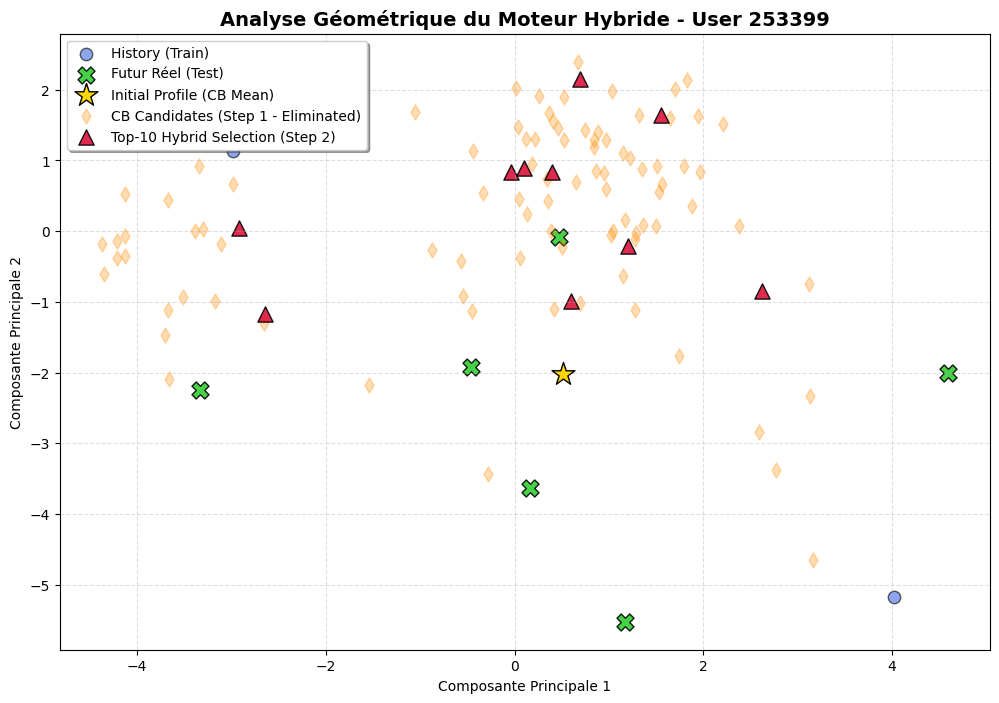

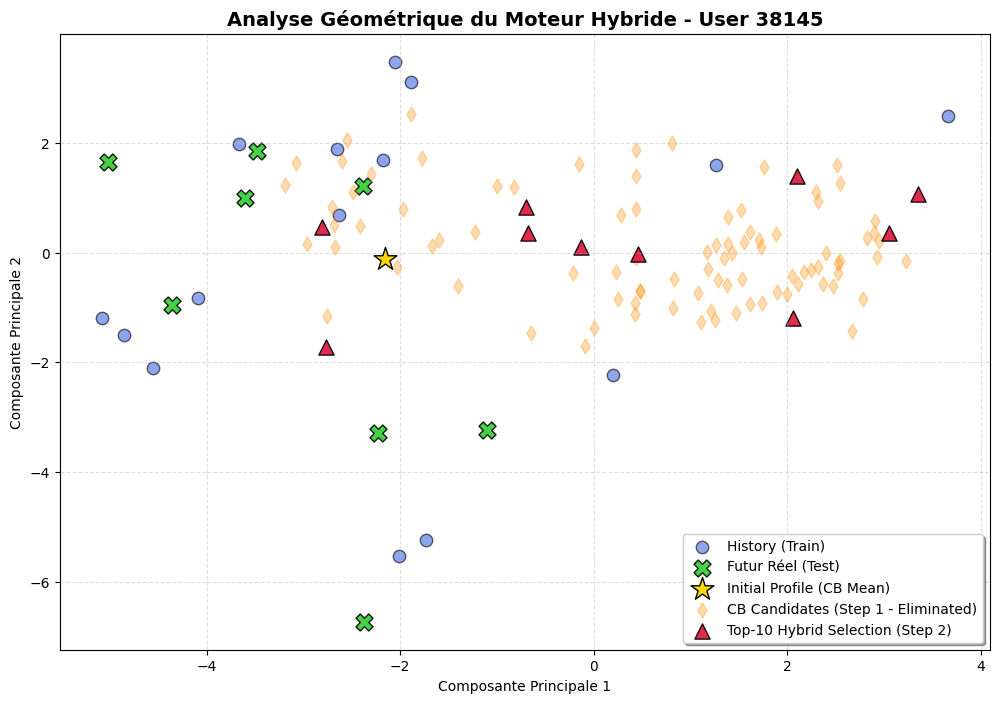

In [42]:
for demo_user in demo_users:
    plot_hybrid_recommendations_2d(
        user_id=demo_user,
        hybrid_model=hybrid_model,
        df_train=train_df,
        df_test=test_df,
        data_loader=data_loader,
        top_n=10,
        pool_size=100
    )

## Fine tuning the best strategy

We are going tu use weights on clicks. We will start by neutralizing popularity (article with the most of clicks) noice and bias using a grid search.

In [45]:
from implicit.nearest_neighbours import TFIDFRecommender, CosineRecommender, BM25Recommender

# Grid search definition
k_values = [10, 20, 50, 100]
weight_strategies = ["raw", "tfidf", "bm25"]
bm25_b_values = [0.5, 0.75] # BM25 parameter B

results = []

print("🚀 Launching the Fine-Tuning of the CF Item-Item model...\n")

for strategy in weight_strategies:
    # 1. Preparation of the matrix according to the weighting strategy
    if strategy == "raw":
        current_matrix = user_item_matrix.astype(np.float32)
        # For 'raw', we only loop once on K
        for K in k_values:
            print(f"Testing: Strategy={strategy} | K={K}")
            model = CosineRecommender(K=K)
            model.fit(current_matrix, show_progress=False)

            acc5 = evaluate_implicit_model(model, current_matrix, test_df, item_to_idx, idx_to_item, topk=5)
            acc10 = evaluate_implicit_model(model, current_matrix, test_df, item_to_idx, idx_to_item, topk=10)

            results.append({"strategy": strategy, "K": K, "BM25_B": "N/A", "Accuracy@5": acc5, "Accuracy@10": acc10})

    elif strategy == "tfidf":
        print("Calcul de la matrice TF-IDF...")
        tfidf_matrix = implicit.nearest_neighbours.tfidf_weight(user_item_matrix).tocsr().astype(np.float32)
        for K in k_values:
            print(f"Testing: Strategy={strategy} | K={K}")
            model = CosineRecommender(K=K)
            model.fit(tfidf_matrix, show_progress=False)

            acc5 = evaluate_implicit_model(model, tfidf_matrix, test_df, item_to_idx, idx_to_item, topk=5)
            acc10 = evaluate_implicit_model(model, tfidf_matrix, test_df, item_to_idx, idx_to_item, topk=10)

            results.append({"strategy": strategy, "K": K, "BM25_B": "N/A", "Accuracy@5": acc5, "Accuracy@10": acc10})

    elif strategy == "bm25":
        for b in bm25_b_values:
            print(f"Calcul de la matrice BM25 (K1=100, B={b})...")
            # K1=100 est le standard par défaut dans implicit pour la saturation
            bm25_matrix = implicit.nearest_neighbours.bm25_weight(user_item_matrix, K1=100, B=b).tocsr().astype(np.float32)
            for K in k_values:
                print(f"Testing: Strategy={strategy} | K={K} | B={b}")
                model = CosineRecommender(K=K)
                model.fit(bm25_matrix, show_progress=False)

                acc5 = evaluate_implicit_model(model, bm25_matrix, test_df, item_to_idx, idx_to_item, topk=5)
                acc10 = evaluate_implicit_model(model, bm25_matrix, test_df, item_to_idx, idx_to_item, topk=10)

                results.append({"strategy": strategy, "K": K, "BM25_B": b, "Accuracy@5": acc5, "Accuracy@10": acc10})

# 2. Display the results
df_tuning = pd.DataFrame(results)
df_tuning = df_tuning.sort_values(by="Accuracy@5", ascending=False).reset_index(drop=True)

print("\n📊 COMPARATIVE TABLE OF THE FINE-TUNING :")
display(df_tuning)

print(f"\n🏆 Best configuration found: Strategy={df_tuning.loc[0, 'strategy']} | K={df_tuning.loc[0, 'K']} | B={df_tuning.loc[0, 'BM25_B']} with Accuracy@5 = {df_tuning.loc[0, 'Accuracy@5']}")

🚀 Launching the Fine-Tuning of the CF Item-Item model...

Testing: Strategy=raw | K=10


/Users/ikusawalaetitia/Documents/oc-projects/python/aiengineer/P10-content_recommandation_app/.venv/lib/python3.12/site-packages/implicit/utils.py:164: ParameterWarning: Method expects CSR input, and was passed coo_matrix instead. Converting to CSR took 0.004275083541870117 seconds
  warnings.warn(


Testing: Strategy=raw | K=20


/Users/ikusawalaetitia/Documents/oc-projects/python/aiengineer/P10-content_recommandation_app/.venv/lib/python3.12/site-packages/implicit/utils.py:164: ParameterWarning: Method expects CSR input, and was passed coo_matrix instead. Converting to CSR took 0.003963947296142578 seconds
  warnings.warn(


Testing: Strategy=raw | K=50


...

Testing: Strategy=bm25 | K=100 | B=0.75


/Users/ikusawalaetitia/Documents/oc-projects/python/aiengineer/P10-content_recommandation_app/.venv/lib/python3.12/site-packages/implicit/utils.py:164: ParameterWarning: Method expects CSR input, and was passed coo_matrix instead. Converting to CSR took 0.003924846649169922 seconds
  warnings.warn(



📊 COMPARATIVE TABLE OF THE FINE-TUNING :


,strategy,K,BM25_B,Accuracy@5,Accuracy@10
0,bm25,50,0.5,0.0126,0.0254
1,bm25,100,0.5,0.0126,0.0256
2,raw,10,N/A,0.0122,0.0222
3,raw,50,N/A,0.0122,0.0308
4,raw,100,N/A,0.0121,0.0269
5,bm25,100,0.75,0.0121,0.0226
6,tfidf,50,N/A,0.0116,0.0281
7,tfidf,100,N/A,0.0113,0.0248
8,bm25,50,0.75,0.0113,0.0212
9,tfidf,10,N/A,0.0107,0.0185



🏆 Best configuration found: Strategy=bm25 | K=50 | B=0.5 with Accuracy@5 = 0.0126
